In [3]:
import warnings
warnings.filterwarnings('ignore')  # 忽略所有警告

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils import data
import random


# 设置随机种子
seed = 20251130
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed) 

### 数据探索

In [4]:
# 查看数据
path = './class_train.csv'
dd = pd.read_csv(path)
print(dd.head())
print()
print(dd['label'].value_counts())

        text  label
0  Gilmartin      0
1       Pett      0
2      Dunne      0
3     Pawson      0
4    Hurrell      0

label
0    4245
1     207
Name: count, dtype: int64


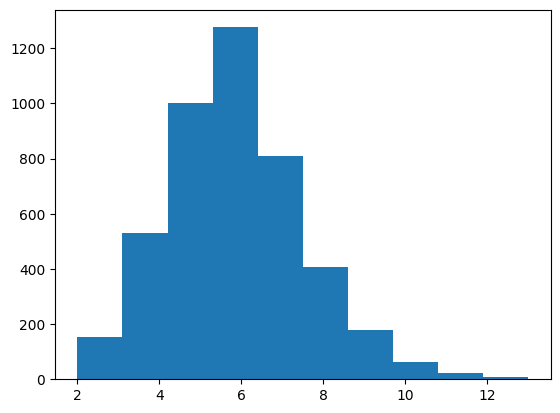

13 2


In [5]:
# 句子长度分析
text_len = [len(i) for i in dd['text']]
plt.hist(text_len)
plt.show()
print(max(text_len), min(text_len))

### 数据预处理

In [6]:
# 基本参数 config
def vacab_build(data, col='text', topK=200):
    # 构建词表 word2id
    vocab = []
    for i in data[col]:
        vocab.extend(list(i.lower()))

    vocab_se = pd.Series(vocab)
    print(vocab_se.value_counts().head())

    vocab = vocab_se.value_counts().index.tolist()[:topK]  # 取频率最高的 topK token

    WORD_PAD = "<PAD>"
    WORD_UNK = "<UNK>"
    # WORD_PAD_ID = 0
    # WORD_UNK_ID = 1

    vocab = [WORD_PAD, WORD_UNK] + list(set(vocab))
    VOCAB_SIZE = len(vocab)

    print(vocab[:10])

    vocab_dict = {k: v for v, k in enumerate(vocab)}
    
    return vocab, vocab_dict, VOCAB_SIZE

# 词表大小，vocab_dict: word2id; vocab: id2word
vocab, vocab_dict, VOCAB_SIZE = vacab_build(dd)
print(VOCAB_SIZE)

a    3363
e    2262
n    2054
r    2038
o    1852
Name: count, dtype: int64
['<PAD>', '<UNK>', 'u', 'd', 'o', 'i', 'w', 't', 'y', 'l']
30


In [7]:
# 定义数据集 Dataset
class Dataset(data.Dataset):
    def __init__(self, split='train'):
        path = './class_' + str(split) + '.csv'
        self.data = pd.read_csv(path)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, i):
        text = self.data.loc[i, 'text']
        label = self.data.loc[i, 'label']

        return text, label

# 实例化 Dataset
dataset = Dataset('train')
print(len(dataset))
print(dataset[0])

4452
('Gilmartin', np.int64(0))


In [8]:
# 设置数据参数
MAX_LEN = 13
BATCH_SIZE = 64

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('my device:', DEVICE)

# 句子批处理函数
def collate_fn(batch, max_len=MAX_LEN, vocab_dict=vocab_dict):
    # [(text1, label1), (text2, label2), (3, 3)...]
    sents = [i[0][:max_len] for i in batch]
    labels = [i[1] for i in batch]

    inputs = []
    WORD_PAD_ID = vocab_dict["<PAD>"]
    WORD_UNK_ID = vocab_dict["<UNK>"]
    for sent in sents:
        sent = [vocab_dict.get(i.lower(), WORD_UNK_ID) for i in list(sent)]
        pad_len = MAX_LEN - len(sent)
        sent = pad_len * [WORD_PAD_ID] + sent
        inputs.append(sent)

    inputs = torch.tensor(inputs)
    labels = torch.LongTensor(labels)

    return inputs.to(DEVICE), labels.to(DEVICE)

# 测试 loader
loader = data.DataLoader(dataset,
                         batch_size=BATCH_SIZE,
                         collate_fn=collate_fn,
                         shuffle=True,
                         drop_last=False)

inputs, labels = iter(loader).__next__()
print(inputs.shape)
print(inputs)
print(labels)

my device: cpu
torch.Size([64, 13])
tensor([[ 0,  0,  0,  0,  0,  0,  0, 14, 21,  8, 13, 25, 16],
        [ 0,  0,  0,  0,  0,  0,  0, 14, 21, 19, 19, 21, 18],
        [ 0,  0,  0,  0,  0,  0,  0, 21, 10, 10,  4,  2,  3],
        [ 0,  0,  0,  0,  0,  0,  0,  0, 21, 19, 28, 13, 19],
        [ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0, 16,  5,  2],
        [ 0,  0,  0,  0,  0,  0,  0,  0,  2,  7,  9, 13,  8],
        [ 0,  0,  0,  0,  0,  0,  0, 14, 21,  8, 13, 25, 16],
        [ 0,  0,  0,  0,  0,  0,  0,  0,  0, 13, 14, 14, 21],
        [ 0,  0,  0,  0,  0,  0,  0,  0,  4, 14, 28, 21, 15],
        [ 0,  0,  0,  0,  0,  0,  0,  0, 25, 21, 15,  5, 28],
        [ 0,  0,  0,  0,  0,  0,  0, 25, 21,  8, 15,  4, 19],
        [ 0,  0,  0,  0,  0, 13, 27, 13, 19,  3, 13,  9,  9],
        [ 0,  0,  0,  0,  0,  0,  0, 13,  9,  9,  5, 15, 25],
        [ 0,  0,  0,  0,  0,  0,  0, 22, 16,  4,  2, 19,  8],
        [ 0,  0,  0,  0,  0,  0,  0, 24, 13, 10, 14,  4, 15],
        [ 0,  0,  0,  0,  0,  0,  

### 模型训练

In [9]:
# 定义模型结构
class Model(nn.Module):
    def __init__(self, vocab_size, max_len, input_dim, hidden_dim, num_layers, output_dim, word_pad_id=0):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, input_dim, padding_idx=word_pad_id)

        # 多种 rnn
        self.rnn = nn.RNN(input_dim, hidden_dim, num_layers, batch_first=True, bidirectional=True)
        self.gru = nn.GRU(input_dim, hidden_dim, num_layers, batch_first=True, bidirectional=True)
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True, bidirectional=True)

        self.l1 = nn.Linear(max_len*hidden_dim*2, hidden_dim*2)
        self.l2 = nn.Linear(hidden_dim*2, output_dim)

    def forward(self, inputs):
        out = self.embed(inputs)
        # out, _ = self.rnn(out)
        # out, _ = self.gru(out)
        out, _ = self.lstm(out)
        out = out.reshape(out.shape[0], -1)     # batch * (max_len * hidden_dim * 2)
        out = F.relu(self.l1(out))              # batch * (hidden_dim*2)
        out = nn.Softmax(dim=-1)(self.l2(out))  # batch * 2

        return out

In [10]:
# 设置超参数
INPUT_DIM = 32
HIDDEN_DIM = 32
NUM_LAYERS = 1
OUTPUT_DIM = 2
EPOCH = 20
LR = 1e-3
WORD_PAD_ID = vocab_dict["<PAD>"]

model = Model(VOCAB_SIZE, MAX_LEN, INPUT_DIM, HIDDEN_DIM, NUM_LAYERS, OUTPUT_DIM, WORD_PAD_ID).to(DEVICE)
print(model)

def train():
    # 交叉熵损失
    loss_fn = nn.CrossEntropyLoss(weight=torch.tensor([1.0, 100.0]))
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR)

    # 训练模型
    model.train()
    for e in range(EPOCH):
        for idx, (inputs, labels) in enumerate(loader):
            # 前向传播，计算分类结果
            out = model(inputs)
            # 计算损失
            loss = loss_fn(out, labels)
            # 反向传播，计算梯度
            loss.backward()
            # 参数更新
            optimizer.step()
            # 梯度清零
            optimizer.zero_grad()

            if idx % 10 == 0:
                out = out.argmax(dim=-1)
                acc = (out == labels).sum().item() / len(labels)

                print('>>epoch:', e,
                      '\tbatch:', idx+1,
                      '\tloss:', loss.item(),
                      '\tacc:', acc)
                
train()

Model(
  (embed): Embedding(30, 32, padding_idx=0)
  (rnn): RNN(32, 32, batch_first=True, bidirectional=True)
  (gru): GRU(32, 32, batch_first=True, bidirectional=True)
  (lstm): LSTM(32, 32, batch_first=True, bidirectional=True)
  (l1): Linear(in_features=832, out_features=64, bias=True)
  (l2): Linear(in_features=64, out_features=2, bias=True)
)
>>epoch: 0 	batch: 1 	loss: 0.695807158946991 	acc: 0.75
>>epoch: 0 	batch: 11 	loss: 0.5251078009605408 	acc: 0.078125
>>epoch: 0 	batch: 21 	loss: 0.48242998123168945 	acc: 0.046875
>>epoch: 0 	batch: 31 	loss: 0.47854116559028625 	acc: 0.046875
>>epoch: 0 	batch: 41 	loss: 0.43718796968460083 	acc: 0.0625
>>epoch: 0 	batch: 51 	loss: 0.6002870202064514 	acc: 0.1875
>>epoch: 0 	batch: 61 	loss: 0.4510645568370819 	acc: 0.78125
>>epoch: 1 	batch: 1 	loss: 0.3518594205379486 	acc: 0.84375
>>epoch: 1 	batch: 11 	loss: 0.3453955054283142 	acc: 0.921875
>>epoch: 1 	batch: 21 	loss: 0.3454296886920929 	acc: 0.84375
>>epoch: 1 	batch: 31 	loss: 0.

### 模型测试

In [9]:
# 模型测试
out_list = []
labels_list = []
pred_list = []

def test():
    test_dataset = Dataset('test')
    test_loader = data.DataLoader(test_dataset,
                                  batch_size=BATCH_SIZE,
                                  collate_fn=collate_fn,
                                  shuffle=True)

    loss_fn = nn.CrossEntropyLoss()

    model.eval()
    for idx, (inputs, labels) in enumerate(test_loader):
        out = model(inputs)
        loss = loss_fn(out, labels)

        out_list.append(out)
        labels_list.append(labels)

        # if idx % 10 == 0:
        #     print('>>batch:', idx, '\tloss:', loss.item())

    correct = 0
    sumz = 0
    for i in range(len(out_list)):
        out = out_list[i].argmax(dim=-1)
        pred_list.append(out)
        correct = (out == labels_list[i]).sum().item() +correct
        sumz = sumz+len(labels_list[i])

    print('>>acc:', correct/sumz)
    
test()

>>acc: 0.9750673854447439


In [10]:
# 从tensor转为list
y_pred = []
for i in pred_list:
    y_pred.extend(i.detach().numpy())
    
y_true = []
for i in labels_list:
    y_true.extend(i.detach().numpy())

In [11]:
# 计算评价指标
from sklearn.metrics import roc_auc_score, classification_report

auc = roc_auc_score(y_true, y_pred)
print(f'AUC: {round(auc,4)}')

print()

report = classification_report(y_true, y_pred, digits=4)
print(report)

AUC: 0.9713

              precision    recall  f1-score   support

           0     0.9986    0.9754    0.9868      1423
           1     0.6277    0.9672    0.7613        61

    accuracy                         0.9751      1484
   macro avg     0.8131    0.9713    0.8741      1484
weighted avg     0.9833    0.9751    0.9776      1484

